# AdaBoost — Churn Prediction Model

Training an AdaBoost classifier on the feature-engineered churn dataset.
We'll try different hyperparameters and pick the best one.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

## 1 · Data Loading & Prep

Dropping features that leak the churn outcome:

| Feature | Why it leaks |
|:--------|:-------------|
| `Total_Net_Paid` | Churned = 0 (didn't pay — set after churn) |
| `price_change_pct/abs` | Derived from Total_Net_Paid |
| `net_paid_vs_last` | Ratio involving current payment (0 for churned) |
| `Payment_Method` | Set to UNKNOWN after churn |
| `Payment_Timeframe` | All churned = 0 |
| `Days_To_Close_Post_Renewal` | Uses close date (post-outcome) |
| `Total_Renewal_Score_New` | Composite encodes outcome |

In [10]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "model_ready_dataset.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. "
        "Make sure you run the notebook from the repo root or run the data prep pipeline first."
    )

df = pd.read_csv(data_path)
print(f"Loaded shape: {df.shape}")

df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

# ---- DROP LEAKY FEATURES ------------------------------------------------
leaky_cols = [
    "Total_Net_Paid", "price_change_pct", "price_change_abs",
    "net_paid_vs_last", "Payment_Method", "Payment_Timeframe",
    "Days_To_Close_Post_Renewal", "Total_Renewal_Score_New",
    "Renewal_Year",
]
cols_before = set(df.columns)
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
actually_dropped = cols_before - set(df.columns)
print(f"Dropped {len(actually_dropped)} leaky/non-predictive features: {sorted(actually_dropped)}")

# --- SPLIT FIRST, THEN ENCODE --------------------------------------------
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# encode categoricals — fit on train only, transform both
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
if cat_cols:
    ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train.loc[:, cat_cols] = ord_enc.fit_transform(X_train[cat_cols]).astype(int)
    X_test.loc[:, cat_cols] = ord_enc.transform(X_test[cat_cols]).astype(int)

# Validate & ensure all columns are numeric
for col in X_train.columns:
    coerced = pd.to_numeric(X_train[col], errors="coerce")
    n_failed = coerced.isna().sum() - X_train[col].isna().sum()
    if n_failed > 0:
        pct = n_failed / len(X_train) * 100
        print(f"  WARNING: '{col}' had {n_failed} ({pct:.1f}%) non-numeric values")

train_medians = X_train.apply(pd.to_numeric, errors="coerce").median()
X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(train_medians)
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(train_medians)

# Compute categorical column indices for SMOTENC
cat_col_indices = [X_train.columns.get_loc(c) for c in cat_cols] if cat_cols else []


print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Loaded shape: (122082, 57)
Dropped 9 leaky/non-predictive features: ['Days_To_Close_Post_Renewal', 'Payment_Method', 'Payment_Timeframe', 'Renewal_Year', 'Total_Net_Paid', 'Total_Renewal_Score_New', 'net_paid_vs_last', 'price_change_abs', 'price_change_pct']

Features: 47
Train: 91115, Test: 22779
Churn rate — Train: 11.12%, Test: 11.12%


## 2 · Baseline AdaBoost Model

In [11]:
ada_pipe_base = ImbPipeline([
    ("smote", SMOTENC(categorical_features=cat_col_indices, random_state=42)),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=1.0,
        random_state=42,
    )),
])
ada_pipe_base.fit(X_train, y_train)

y_pred_base = ada_pipe_base.predict(X_test)
y_prob_base = ada_pipe_base.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1 Score": f1_score(y_test, y_pred_base),
    "ROC AUC": roc_auc_score(y_test, y_prob_base),
}

print("=" * 60)
print("BASELINE ADABOOST RESULTS")
print("=" * 60)
for k, v in baseline_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE ADABOOST RESULTS
Accuracy  : 0.8938
Precision : 0.5134
Recall    : 0.8607
F1 Score  : 0.6432
ROC AUC   : 0.9530

              precision    recall  f1-score   support

         Won       0.98      0.90      0.94     20245
     Churned       0.51      0.86      0.64      2534

    accuracy                           0.89     22779
   macro avg       0.75      0.88      0.79     22779
weighted avg       0.93      0.89      0.90     22779



## 3 · Hyperparameter Tuning

Using RandomizedSearchCV with 3-fold CV for speed.

In [12]:
param_dist = {
    "clf__n_estimators": [50, 100, 150, 200],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    "clf__estimator__max_depth": [1, 2, 3],
}

ada_pipe = ImbPipeline([
    ("smote", SMOTENC(categorical_features=cat_col_indices, random_state=42)),
    ("clf", AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42)),
])

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    ada_pipe, param_dist,
    n_iter=12,
    cv=cv_strat,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)
random_search.fit(X_train, y_train)

print(f"\nBest params: {random_search.best_params_}")
print(f"Best F1 (CV): {random_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'clf__n_estimators': 100, 'clf__learning_rate': 1.0, 'clf__estimator__max_depth': 3}
Best F1 (CV): 0.7546


## 4 · Best Model Evaluation

In [13]:
best_ada = random_search.best_estimator_
best_ada_clf = best_ada.named_steps['clf']
y_pred = best_ada.predict(X_test)
y_prob = best_ada.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_prob),
}

print("=" * 60)
print("TUNED ADABOOST RESULTS")
print("=" * 60)
for k, v in tuned_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED ADABOOST RESULTS
Accuracy  : 0.9369
Precision : 0.6727
Recall    : 0.8425
F1 Score  : 0.7481
ROC AUC   : 0.9718

              precision    recall  f1-score   support

         Won       0.98      0.95      0.96     20245
     Churned       0.67      0.84      0.75      2534

    accuracy                           0.94     22779
   macro avg       0.83      0.90      0.86     22779
weighted avg       0.95      0.94      0.94     22779



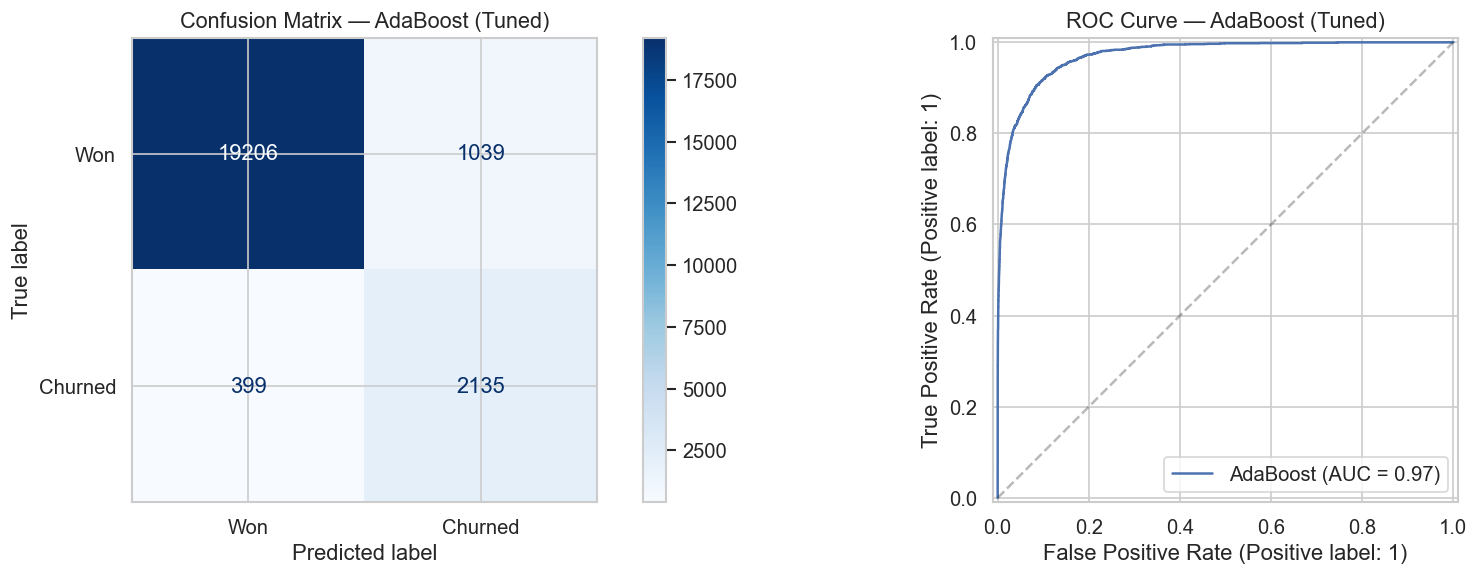

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Won", "Churned"], ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Confusion Matrix — AdaBoost (Tuned)", fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="AdaBoost")
axes[1].set_title("ROC Curve — AdaBoost (Tuned)", fontsize=13)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.show()

## 5 · Feature Importance

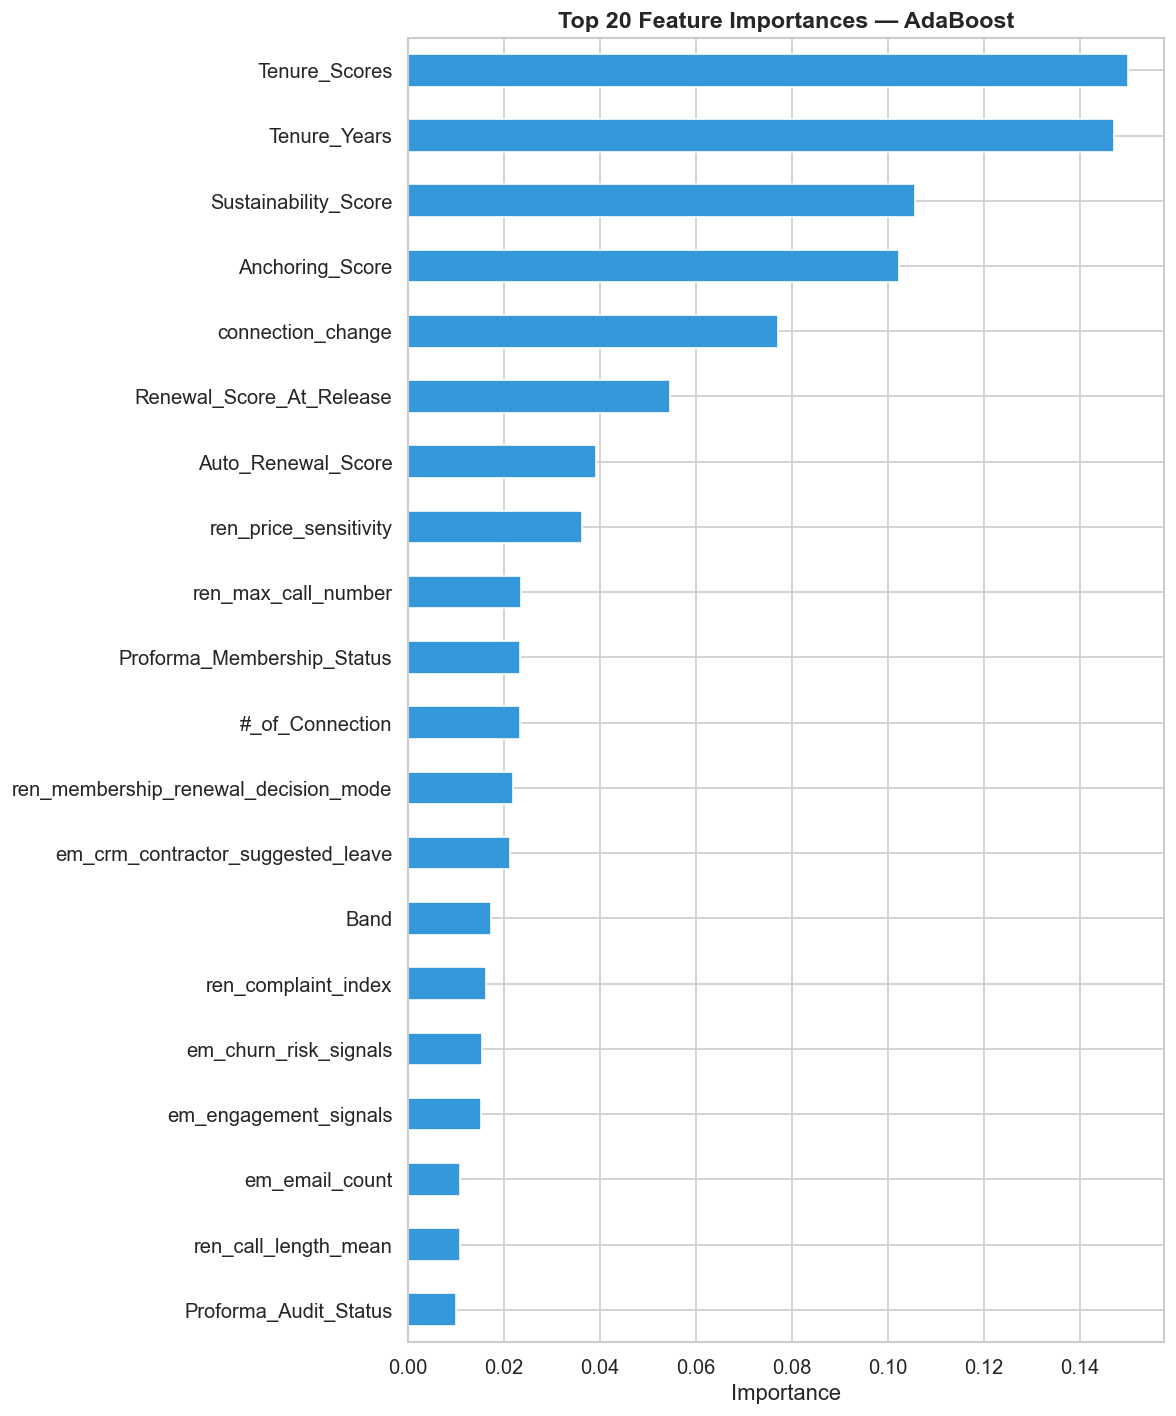

In [15]:
importances = best_ada_clf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
feat_imp.tail(20).plot.barh(ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Top 20 Feature Importances — AdaBoost", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Summary

In [16]:
summary = pd.DataFrame({"Baseline": baseline_metrics, "Tuned": tuned_metrics})
summary = summary.round(4)
try:
    print(summary.to_markdown())
except ImportError:
    print(summary.to_string())

|           |   Baseline |   Tuned |
|:----------|-----------:|--------:|
| Accuracy  |     0.8938 |  0.9369 |
| Precision |     0.5134 |  0.6727 |
| Recall    |     0.8607 |  0.8425 |
| F1 Score  |     0.6432 |  0.7481 |
| ROC AUC   |     0.953  |  0.9718 |
